# Training KongNet from Scratch on CoNIC


## About this notebook

This notebook demonstrates the new structured-dense training workflow in `tiatoolbox.models.training` using a KongNet model trained from scratch on the CoNIC patch dataset.

Workflow used here:
1. Load the PNG patches and paired annotation stores created from CoNIC `images.npy` and `labels.npy`.
2. Build a full 3-channel supervision target for each CoNIC class head: `mask`, `boundary`, and `centroid`.
3. Instantiate KongNet and derive a `StructuredDenseTask` with `build_kongnet_training_task()`.
4. Train for a few epochs on a small demo subset.
5. Run inference on a few validation patches and visualise the learned mask, boundary, centroid, and peak outputs.

This is intentionally a lightweight demonstration. Challenge-grade KongNet training would use the full dataset, more augmentation, larger batches, and substantially more epochs.


## Optional: Colab setup


In [ ]:
%%bash
python -m pip install --quiet --upgrade pip
python -m pip install --quiet tiatoolbox


If you are using Colab and ran the install cell for the first time, restart the runtime before continuing.


## Imports and configuration


In [1]:
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from tiatoolbox.models.architecture.kongnet import KongNet
from tiatoolbox.models.training import (
    BoundaryTargetBuilder,
    CompositeTargetBuilder,
    GaussianHeatmapTargetBuilder,
    MaskTargetBuilder,
    PatchAnnotationDataset,
    StackedTargetBuilder,
    Trainer,
    TrainerConfig,
    build_kongnet_training_task,
    get_annotation_augmentation,
)

rng = np.random.default_rng(7)
torch.manual_seed(7)

SUPERVISION_CHANNELS = ("mask", "boundary", "centroid")

device = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.dpi"] = 140
print(f"Using device: {device}")

def load_rgb_image(path: Path) -> np.ndarray:
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def stack_head_channel_maps(
    target_dict: dict[str, torch.Tensor],
    ordered_keys: list[str],
    channel_index: int,
) -> np.ndarray:
    return np.stack(
        [target_dict[key][channel_index].cpu().numpy() for key in ordered_keys],
        axis=-1,
    )

def extract_kongnet_head_channel_maps(
    model: KongNet,
    logits: torch.Tensor,
    ordered_keys: list[str],
) -> dict[str, np.ndarray]:
    probabilities = torch.sigmoid(logits).detach().cpu()
    head_specs = {spec.name: spec for spec in model.training_output_spec}
    channel_maps = {channel_name: [] for channel_name in SUPERVISION_CHANNELS}

    for head_key in ordered_keys:
        head_spec = head_specs[head_key]
        head_probabilities = probabilities[:, head_spec.channel_slice, :, :]
        for channel_index, channel_name in enumerate(SUPERVISION_CHANNELS):
            channel_maps[channel_name].append(head_probabilities[:, channel_index].numpy())

    return {
        channel_name: np.stack(head_maps, axis=-1)
        for channel_name, head_maps in channel_maps.items()
    }


|2026-03-17|23:59:46.097| [WARNING] /home/mark-eastwood/miniforge3/envs/comfyui/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Using device: cuda


## Locate the converted CoNIC data

This notebook assumes you already ran `examples/prepare_conic_training_data.py`, which should have created:
- `images_png/` containing one PNG patch per CoNIC sample
- `annotation_stores/` containing one `.db` store per PNG patch


In [2]:
data_root = Path("/media/mark-eastwood/Work/Data/Conic")
images_dir = data_root / "images_png"
stores_dir = data_root / "annotation_stores"

if not images_dir.exists() or not stores_dir.exists():
    raise FileNotFoundError(
        "Expected `images_png/` and `annotation_stores/` inside the CoNIC directory. "
        "Run `examples/prepare_conic_training_data.py` first."
    )

image_paths = sorted(images_dir.glob("*.png"))
store_paths = [stores_dir / f"{path.stem}.db" for path in image_paths]
missing_stores = [path for path in store_paths if not path.exists()]
if missing_stores:
    raise FileNotFoundError(f"Missing annotation stores for: {missing_stores[:5]}")

paired_samples = list(zip(image_paths, store_paths, strict=True))
print(f"Found {len(paired_samples)} PNG/store pairs.")
paired_samples[:3]


Found 4981 PNG/store pairs.


[(PosixPath('/media/mark-eastwood/Work/Data/Conic/images_png/00000.png'),
  PosixPath('/media/mark-eastwood/Work/Data/Conic/annotation_stores/00000.db')),
 (PosixPath('/media/mark-eastwood/Work/Data/Conic/images_png/00001.png'),
  PosixPath('/media/mark-eastwood/Work/Data/Conic/annotation_stores/00001.db')),
 (PosixPath('/media/mark-eastwood/Work/Data/Conic/images_png/00002.png'),
  PosixPath('/media/mark-eastwood/Work/Data/Conic/annotation_stores/00002.db'))]

## Define a compact KongNet supervision recipe

KongNet has 6 heads on CoNIC, with 3 output channels per head in the pretrained architecture. In this example we supervise all 3 channels of every head:

- `mask`: dense per-class foreground map
- `boundary`: dense contour map
- `centroid`: dense Gaussian detection heatmap

That gives a substantially more faithful KongNet-style training recipe while still using the generic structured-dense training additions from the recent PRs.


In [3]:
conic_class_dict = {
    0: "Neutrophil",
    1: "Epithelial",
    2: "Lymphocyte",
    3: "Plasma",
    4: "Eosinophil",
    5: "Connective",
}
ordered_head_keys = [label.lower() for label in conic_class_dict.values()]

target_builder = CompositeTargetBuilder(
    {
        label.lower(): StackedTargetBuilder(
            {
                "mask": MaskTargetBuilder(
                    where=f'props["class"] == "{label}"',
                    class_mapping=None,
                    default_label=0,
                ),
                "boundary": BoundaryTargetBuilder(
                    where=f'props["class"] == "{label}"',
                    line_width=1,
                ),
                "centroid": GaussianHeatmapTargetBuilder(
                    where=f'props["class"] == "{label}"',
                    sigma=2.0,
                ),
            }
        )
        for label in conic_class_dict.values()
    }
)

train_augmentation = get_annotation_augmentation(
    "light",
    target_builder=target_builder,
)

demo_train_size = 512
demo_val_size = 128
demo_size = demo_train_size + demo_val_size
if demo_size > len(paired_samples):
    raise ValueError(
        f"Requested {demo_size} demo samples, but only found {len(paired_samples)} pairs."
    )

demo_indices = rng.permutation(len(paired_samples))[:demo_size]
train_indices = demo_indices[:demo_train_size]
val_indices = demo_indices[demo_train_size:]

train_pairs = [paired_samples[index] for index in train_indices]
val_pairs = [paired_samples[index] for index in val_indices]

print(f"Demo train pairs: {len(train_pairs)}")
print(f"Demo val pairs: {len(val_pairs)}")


Demo train pairs: 512
Demo val pairs: 128


## Build datasets and preview one target sample


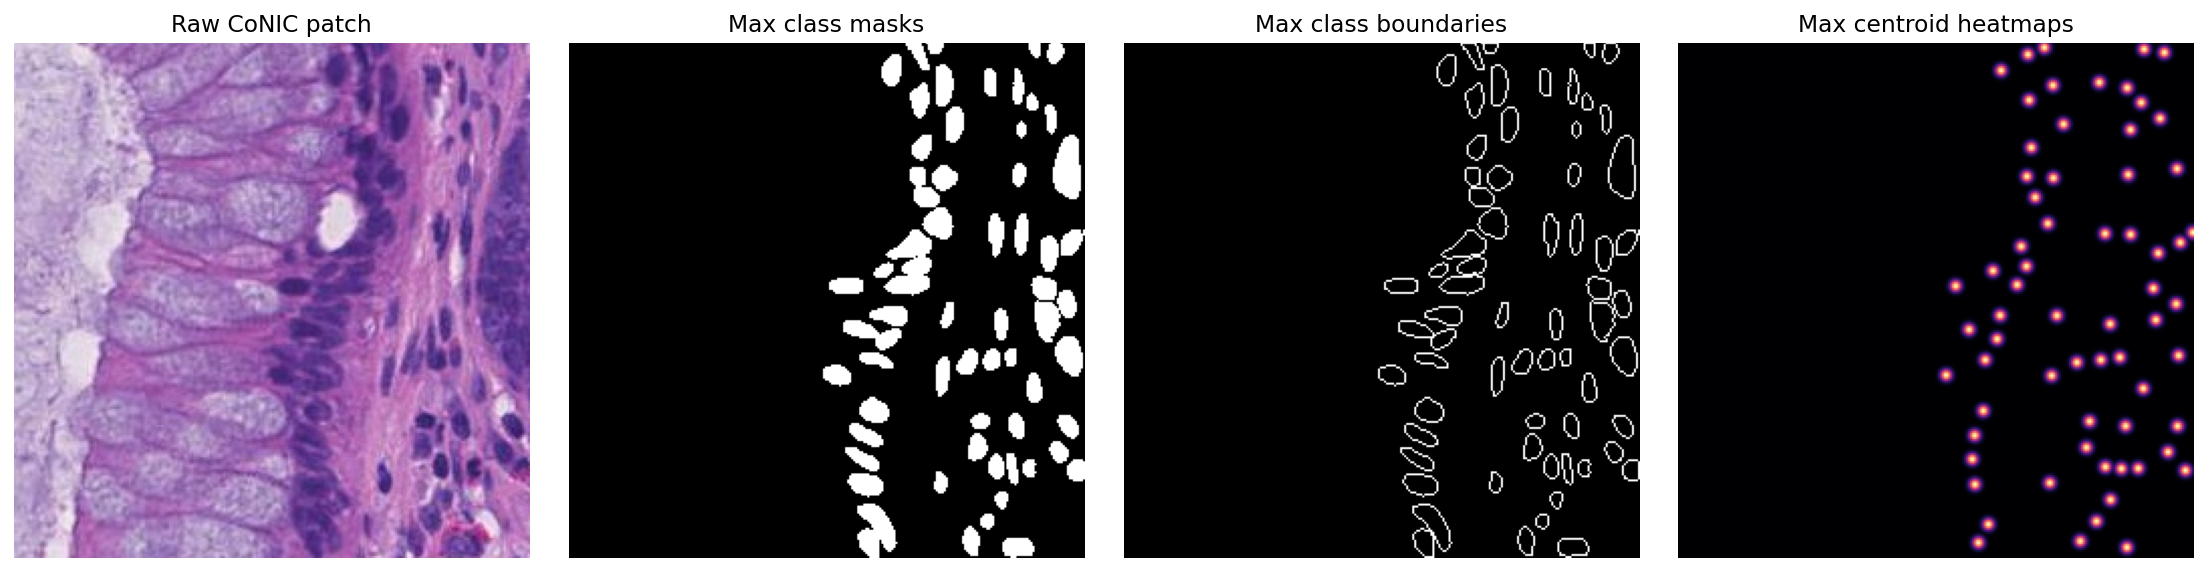

In [4]:
train_dataset = PatchAnnotationDataset(
    patch_inputs=[image_path for image_path, _ in train_pairs],
    annotation_stores=[store_path for _, store_path in train_pairs],
    target_builder=target_builder,
    pair_transform=train_augmentation.pair_transform,
    image_transform=KongNet.preproc,
)

val_dataset = PatchAnnotationDataset(
    patch_inputs=[image_path for image_path, _ in val_pairs],
    annotation_stores=[store_path for _, store_path in val_pairs],
    target_builder=target_builder,
    image_transform=KongNet.preproc,
)

preview_image_path, _ = val_pairs[0]
preview_raw = load_rgb_image(preview_image_path)
preview_item = val_dataset[0]
preview_mask_maps = stack_head_channel_maps(preview_item["target"], ordered_head_keys, 0)
preview_boundary_maps = stack_head_channel_maps(preview_item["target"], ordered_head_keys, 1)
preview_centroid_maps = stack_head_channel_maps(preview_item["target"], ordered_head_keys, 2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(preview_raw)
axes[0].set_title("Raw CoNIC patch")
axes[1].imshow(np.max(preview_mask_maps, axis=-1), cmap="gray")
axes[1].set_title("Max class masks")
axes[2].imshow(np.max(preview_boundary_maps, axis=-1), cmap="gray")
axes[2].set_title("Max class boundaries")
axes[3].imshow(np.max(preview_centroid_maps, axis=-1), cmap="magma")
axes[3].set_title("Max centroid heatmaps")
for ax in axes:
    ax.axis("off")
plt.tight_layout()


## Instantiate KongNet and derive the structured dense task

We keep KongNet's native 3-channel-per-head layout and supervise each head as a single stacked dense target.


In [5]:
model = KongNet(
    num_heads=6,
    num_channels_per_head=[3, 3, 3, 3, 3, 3],
    target_channels=[2, 5, 8, 11, 14, 17],
    min_distance=5,
    threshold_abs=0.35,
    class_dict=conic_class_dict,
)

task = build_kongnet_training_task(
    model,
    target_selection="full_head",
    target_keys={head_key: head_key for head_key in ordered_head_keys},
)

pd.DataFrame(
    [
        {
            "head": spec.name,
            "display_name": spec.display_name,
            "channel_slice": str(spec.channel_slice),
            "target_channels": list(spec.target_channels),
            "target_offsets": list(spec.target_channel_offsets),
        }
        for spec in model.training_output_spec
    ]
)


,head,display_name,channel_slice,target_channels,target_offsets
0,neutrophil,Neutrophil,"slice(0, 3, None)",[2],[2]
1,epithelial,Epithelial,"slice(3, 6, None)",[5],[2]
2,lymphocyte,Lymphocyte,"slice(6, 9, None)",[8],[2]
3,plasma,Plasma,"slice(9, 12, None)",[11],[2]
4,eosinophil,Eosinophil,"slice(12, 15, None)",[14],[2]
5,connective,Connective,"slice(15, 18, None)",[17],[2]


## Data loaders and a trainer run

The settings below are intentionally conservative so the notebook remains runnable on modest hardware. Increase the subset sizes, batch size, and epoch count for a more serious training run.


In [7]:
batch_size = 8 if device == "cuda" else 1

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

train_output_dir = Path("examples/tmp/15-kongnet-conic-training")
if train_output_dir.exists():
    shutil.rmtree(train_output_dir)

trainer = Trainer(
    model=model,
    task=task,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    config=TrainerConfig(
        max_epochs=30,
        device=device,
        amp=device == "cuda",
        seed=7,
        output_dir=train_output_dir,
        monitor="val_loss",
        monitor_mode="min",
        log_every_n_steps=0,
    ),
)

history = trainer.fit()
history_df = pd.DataFrame(history)
history_df.tail()


|2026-03-18|00:03:16.811| [INFO] Epoch 1/30 | monitor `val_loss`=3.734627 | best=3.734627
|2026-03-18|00:03:40.144| [INFO] Epoch 2/30 | monitor `val_loss`=3.644275 | best=3.644275
|2026-03-18|00:04:03.800| [INFO] Epoch 3/30 | monitor `val_loss`=3.568522 | best=3.568522
|2026-03-18|00:04:26.767| [INFO] Epoch 4/30 | monitor `val_loss`=3.430510 | best=3.430510
|2026-03-18|00:04:49.778| [INFO] Epoch 5/30 | monitor `val_loss`=3.280000 | best=3.280000
|2026-03-18|00:05:13.578| [INFO] Epoch 6/30 | monitor `val_loss`=3.202400 | best=3.202400
|2026-03-18|00:05:37.468| [INFO] Epoch 7/30 | monitor `val_loss`=3.134299 | best=3.134299
|2026-03-18|00:06:00.975| [INFO] Epoch 8/30 | monitor `val_loss`=3.032583 | best=3.032583
|2026-03-18|00:06:24.037| [INFO] Epoch 9/30 | monitor `val_loss`=2.988282 | best=2.988282
|2026-03-18|00:06:47.839| [INFO] Epoch 10/30 | monitor `val_loss`=2.837443 | best=2.837443
|2026-03-18|00:07:11.211| [INFO] Epoch 11/30 | monitor `val_loss`=2.771574 | best=2.771574
|2026-03

,epoch,train_loss,train_neutrophil_loss,train_neutrophil_dice,train_neutrophil_iou,train_epithelial_loss,train_epithelial_dice,train_epithelial_iou,train_lymphocyte_loss,train_lymphocyte_dice,...,val_lymphocyte_iou,val_plasma_loss,val_plasma_dice,val_plasma_iou,val_eosinophil_loss,val_eosinophil_dice,val_eosinophil_iou,val_connective_loss,val_connective_dice,val_connective_iou
25,26.0,1.538899,0.287258,0.465021,0.329399,0.252064,0.508043,0.360541,0.259929,0.458593,...,0.333240,0.227091,0.460482,0.332746,0.280609,0.521154,0.373658,0.246588,0.484186,0.346468
26,27.0,1.484469,0.277083,0.459718,0.326465,0.242953,0.507332,0.360333,0.250872,0.453850,...,0.335300,0.229014,0.463405,0.334470,0.284135,0.522588,0.373115,0.248902,0.478072,0.344198
27,28.0,1.434997,0.267498,0.458830,0.326313,0.234750,0.505947,0.359252,0.242463,0.451497,...,0.306010,0.215174,0.430483,0.308844,0.260358,0.489499,0.349204,0.232593,0.422507,0.304981
28,29.0,1.384916,0.257818,0.453734,0.323782,0.226660,0.501332,0.356377,0.234029,0.444659,...,0.321761,0.206516,0.438996,0.319408,0.245502,0.487063,0.349540,0.222226,0.446833,0.325911
29,30.0,1.339752,0.249104,0.450518,0.322098,0.219276,0.499969,0.355618,0.226312,0.442585,...,0.329163,0.204812,0.451179,0.326182,0.246013,0.518604,0.373084,0.217016,0.424854,0.311548


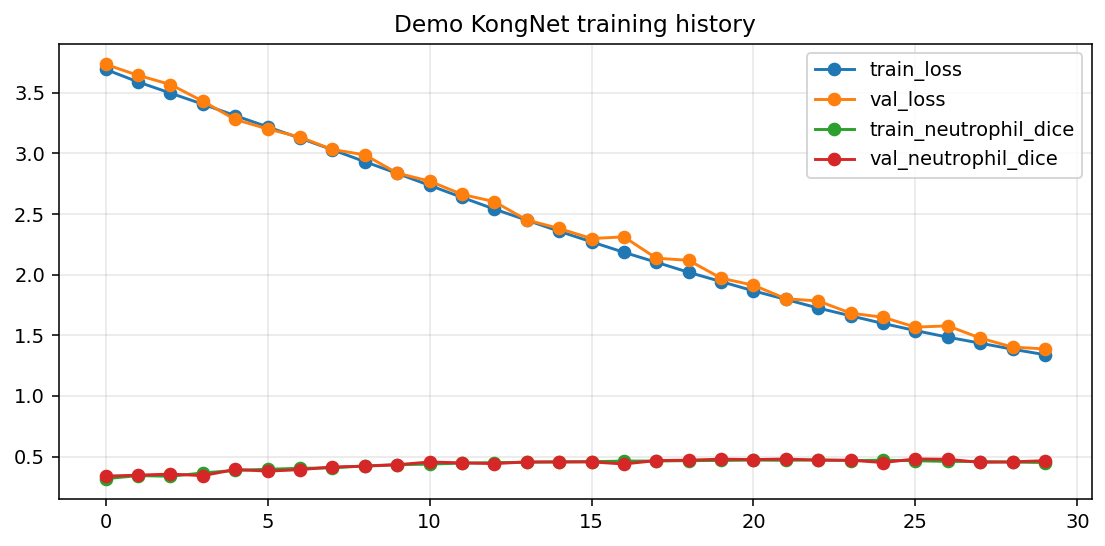

In [8]:
metric_columns = ["train_loss", "val_loss"]
if "train_neutrophil_dice" in history_df:
    metric_columns.extend(["train_neutrophil_dice", "val_neutrophil_dice"])

history_df[metric_columns].plot(marker="o", figsize=(8, 4))
plt.title("Demo KongNet training history")
plt.grid(alpha=0.3)
plt.tight_layout()


## Inference on a few validation patches

We run the newly trained model on a few held-out CoNIC patches, inspect the learned mask, boundary, and centroid probability maps, and then apply KongNet's centroid post-processing to obtain per-class peak detections.


|2026-03-18|01:14:02.788| [WARNING] /media/mark-eastwood/Work/tiatoolbox/tiatoolbox/models/architecture/utils.py:499: FutureWarning: `RegionProperties['mean_intensity']` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties['intensity_mean']` instead. 
  peak["mean_intensity"],

|2026-03-18|01:14:03.296| [WARNING] /tmp/ipykernel_151959/2193442200.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  class_cmap = plt.cm.get_cmap("tab10", len(ordered_head_keys))



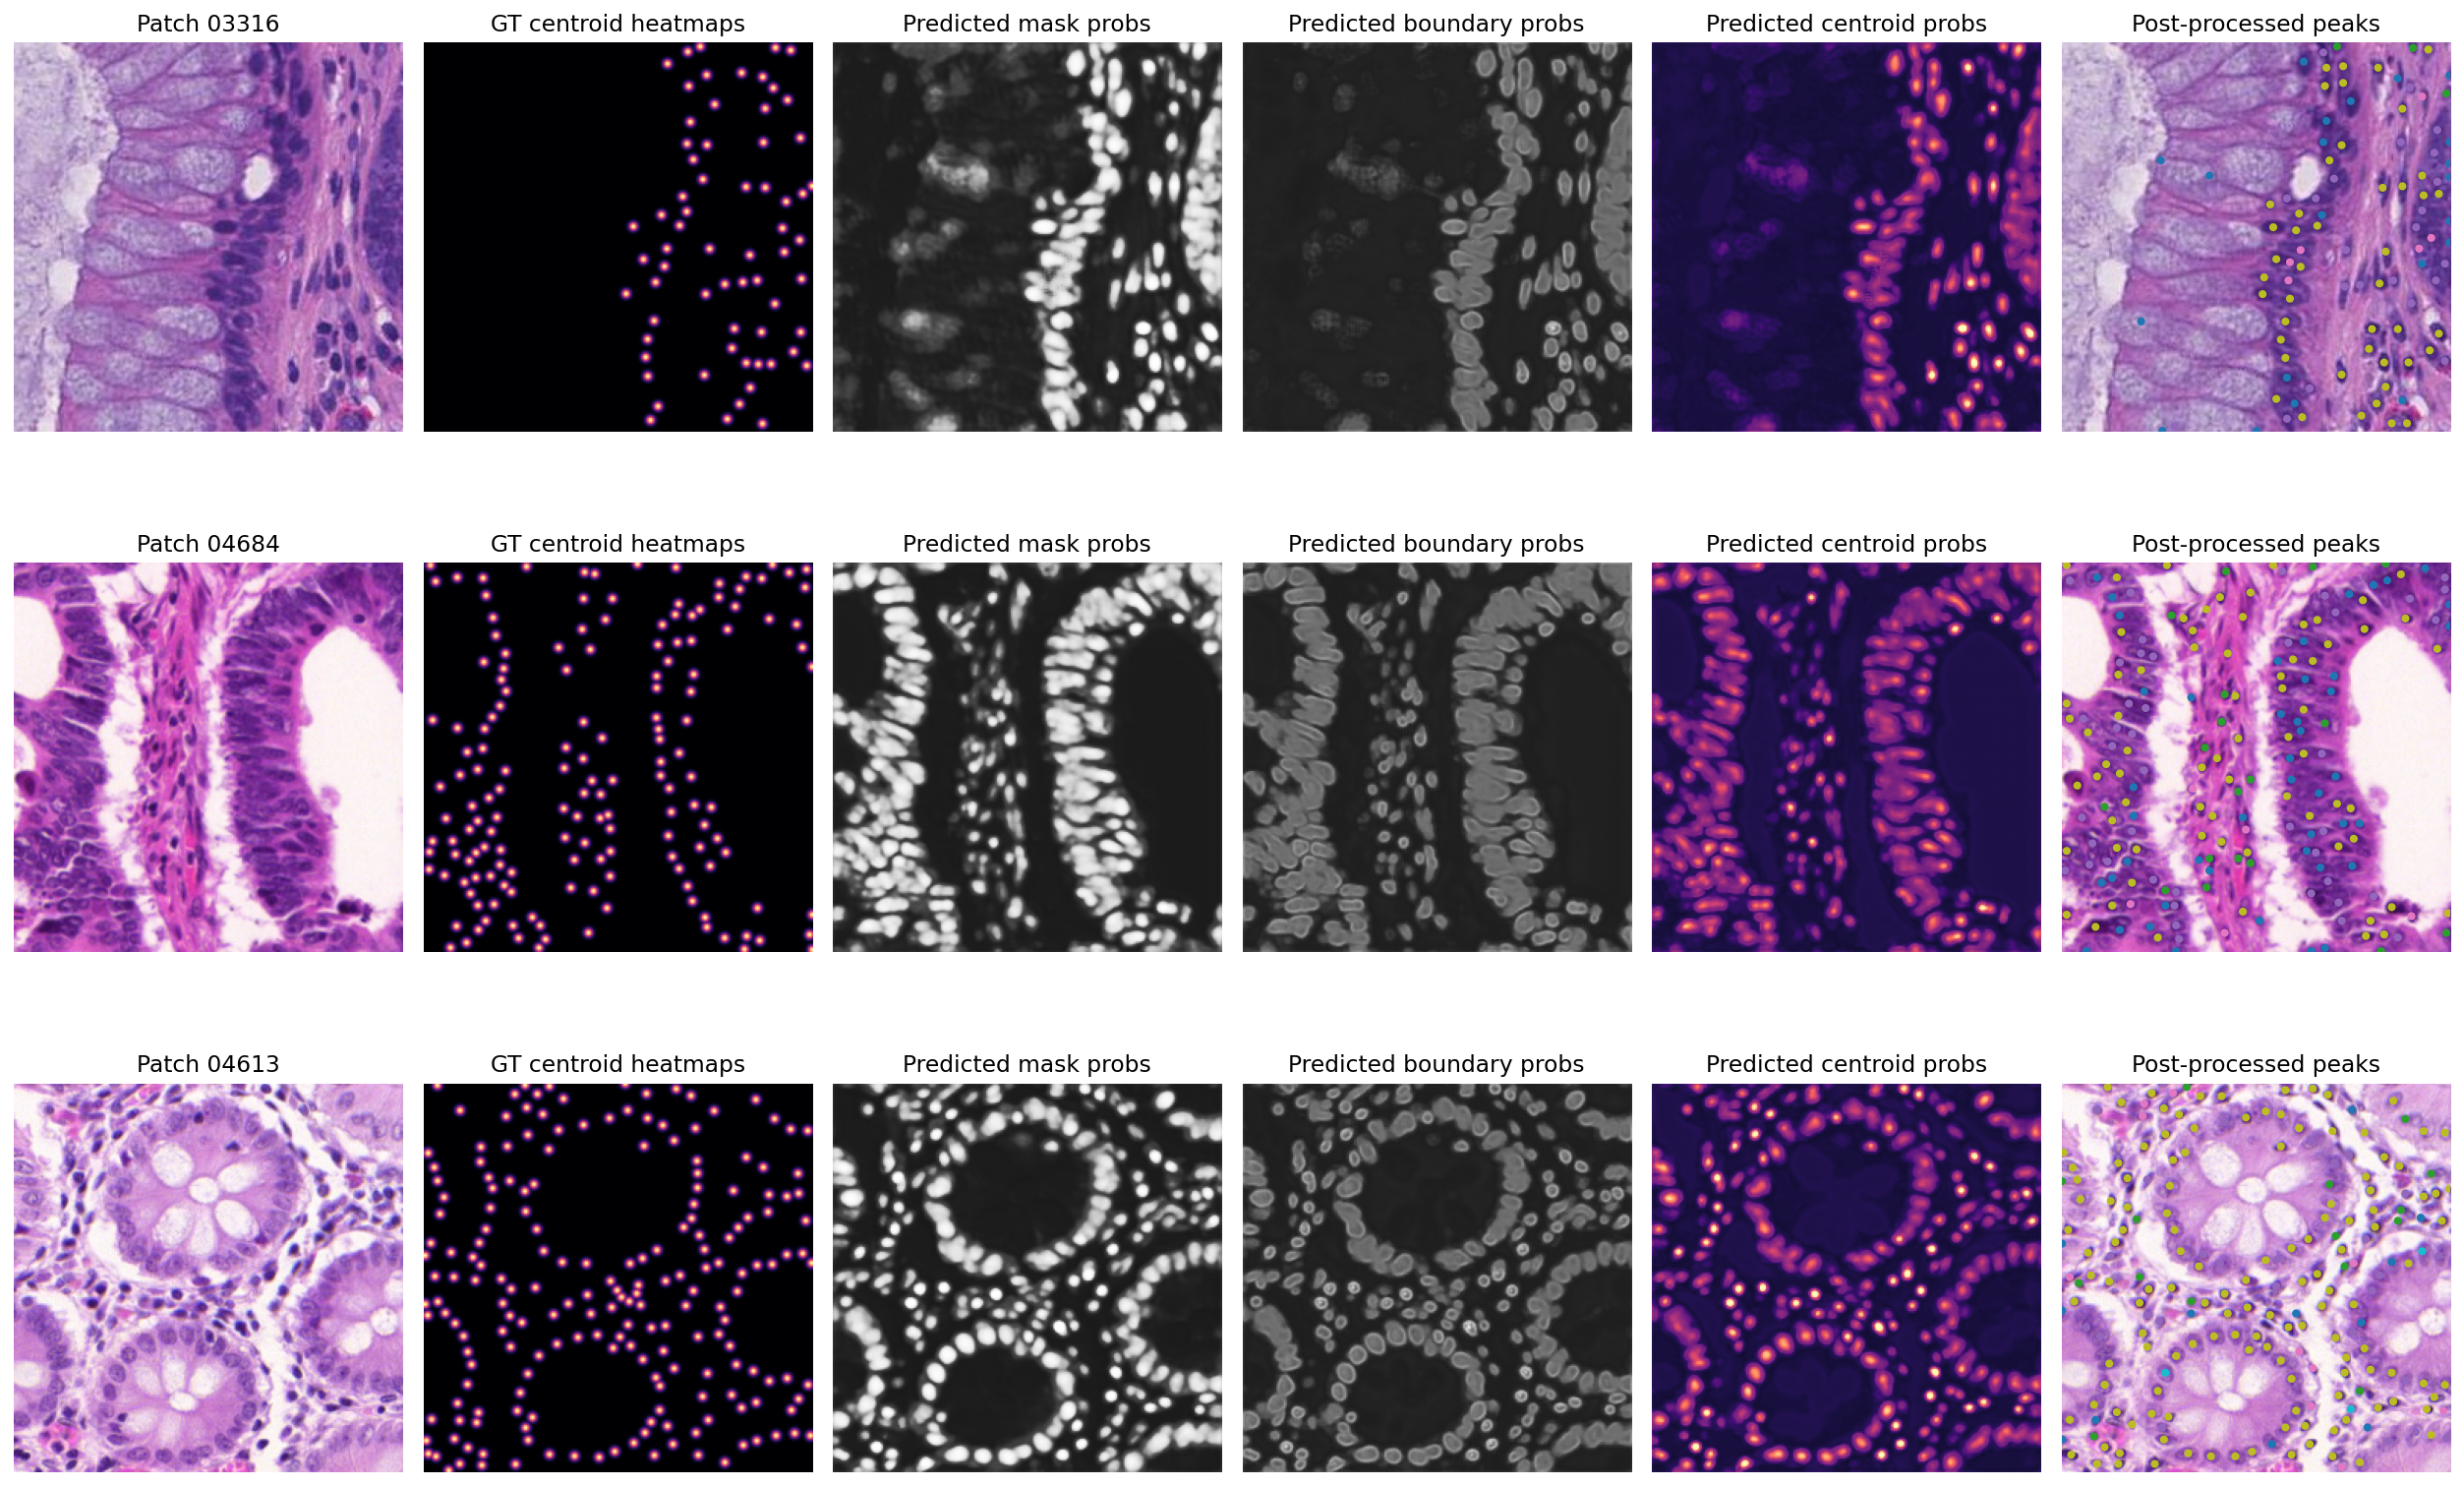

In [10]:
model.eval()

example_count = 3
example_pairs = val_pairs[:example_count]
example_images = [load_rgb_image(image_path) for image_path, _ in example_pairs]
example_batch = torch.from_numpy(
    np.stack([KongNet.preproc(image).astype(np.float32) for image in example_images], axis=0)
)
example_batch_nchw = example_batch.permute(0, 3, 1, 2).to(device)

with torch.no_grad():
    example_logits = model(example_batch_nchw)

pred_component_maps = extract_kongnet_head_channel_maps(model, example_logits, ordered_head_keys)
pred_centroid_maps = pred_component_maps["centroid"]
pred_peak_maps = np.stack([model.postproc(prob_map) for prob_map in pred_centroid_maps], axis=0)
gt_centroid_maps = [
    stack_head_channel_maps(val_dataset[index]["target"], ordered_head_keys, 2)
    for index in range(example_count)
]

class_cmap = plt.cm.get_cmap("tab10", len(ordered_head_keys))
class_colours = {key: class_cmap(index) for index, key in enumerate(ordered_head_keys)}

fig, axes = plt.subplots(example_count, 6, figsize=(18, 4 * example_count))
if example_count == 1:
    axes = np.expand_dims(axes, axis=0)

for row, image in enumerate(example_images):
    peak_map = pred_peak_maps[row]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"Patch {example_pairs[row][0].stem}")

    axes[row, 1].imshow(np.max(gt_centroid_maps[row], axis=-1), cmap="magma")
    axes[row, 1].set_title("GT centroid heatmaps")

    axes[row, 2].imshow(np.max(pred_component_maps["mask"][row], axis=-1), cmap="gray", vmin=0.0, vmax=1.0)
    axes[row, 2].set_title("Predicted mask probs")

    axes[row, 3].imshow(np.max(pred_component_maps["boundary"][row], axis=-1), cmap="gray", vmin=0.0, vmax=1.0)
    axes[row, 3].set_title("Predicted boundary probs")

    axes[row, 4].imshow(np.max(pred_component_maps["centroid"][row], axis=-1), cmap="magma", vmin=0.0, vmax=1.0)
    axes[row, 4].set_title("Predicted centroid probs")

    axes[row, 5].imshow(image)
    peak_y, peak_x, peak_c = np.where(peak_map > 0)
    if len(peak_x) > 0:
        axes[row, 5].scatter(
            peak_x,
            peak_y,
            c=[class_colours[ordered_head_keys[channel]] for channel in peak_c],
            s=10,
        )
    axes[row, 5].set_title("Post-processed peaks")

    for col in range(6):
        axes[row, col].axis("off")

plt.tight_layout()


In [11]:
peak_count_rows = []
for row, (image_path, _) in enumerate(example_pairs):
    row_counts = {"patch": image_path.stem}
    for channel_index, head_key in enumerate(ordered_head_keys):
        row_counts[head_key] = int(pred_peak_maps[row, :, :, channel_index].sum())
    peak_count_rows.append(row_counts)

pd.DataFrame(peak_count_rows)


,patch,neutrophil,epithelial,lymphocyte,plasma,eosinophil,connective
0,03316,10,1,13,3,33,0
1,04684,26,10,25,2,44,0
2,04613,6,8,15,4,106,1


## Next steps

To turn this into a stronger CoNIC training recipe, the first things to scale up are:
- use the full dataset rather than the small demo subset,
- increase `max_epochs`,
- tune the relative weighting and exact target shapes for mask, boundary, and centroid supervision,
- and strengthen augmentation once you decide how aggressively you want to interpolate the stacked target channels.
